In [1]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
from tensorflow.keras.applications import ResNet50V2
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PATH = 'datasets/ISIC_2020_corrected'
os.listdir(PATH)

['multiclass',
 'subset.csv',
 'test_split.csv',
 'train',
 'train.csv',
 'train_resized',
 'train_sd_split.csv',
 'train_split.csv',
 'val_split.csv']

In [3]:
train = pd.read_csv(f'{PATH}/subset.csv')
val = pd.read_csv(f'{PATH}/val_split.csv')
test = pd.read_csv(f'{PATH}/test_split.csv')
train.shape, val.shape

((2319, 9), (4969, 9))

In [4]:
train.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_8130007,IP_5229014,IL_1982348,male,55.0,upper extremity,unknown,benign,0
1,ISIC_4820993,IP_3713422,IL_2860029,male,50.0,torso,unknown,benign,0
2,ISIC_6859051,IP_9927968,IL_7824946,male,35.0,lower extremity,unknown,benign,0
3,ISIC_3216482,IP_4204657,IL_0820225,female,40.0,lower extremity,unknown,benign,0
4,ISIC_7381220,IP_3434100,IL_4512578,female,60.0,torso,unknown,benign,0


In [5]:
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label
    
def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

In [6]:
train_ds = load_ds(train)
val_ds = load_ds(val)
test_ds = load_ds(test)

In [7]:
IMAGE_SIZE = (256, 256, 3)

encoder = ResNet50V2(
    include_top=False,
    input_shape=IMAGE_SIZE,
    weights='imagenet'
)
encoder.trainable = True

inputs = keras.Input(shape=IMAGE_SIZE)
x = keras.layers.Rescaling(1./255)(inputs)
x = encoder(x, training=True)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 256, 256, 3)       0         
                                                                 
 resnet50v2 (Functional)     (None, 8, 8, 2048)        23564800  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1)                 2049      
                                                                 
Total params: 23,566,849
Trainable params: 23,521,409
Non-trainable params: 45,440
____________________________________________

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(name="auc", curve='ROC'), keras.metrics.FalseNegatives(), keras.metrics.TruePositives()]
)

In [9]:
filepath = 'models/checkpoints/baseline2'
cb = tf.keras.callbacks.ModelCheckpoint(
    filepath = filepath,
    monitor="val_auc",
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode="max"
)

In [10]:
history = model.fit(train_ds,
                    epochs=10,
                    validation_data=val_ds,
                    validation_steps=10,
                    callbacks=[cb]
                   )

Epoch 1/10
37/37 [==============================] - 29s 562ms/step - loss: 0.1261 - auc: 0.6173 - false_negatives: 41.0000 - true_positives: 0.0000e+00 - val_loss: 0.0947 - val_auc: 0.7144 - val_false_negatives: 12.0000 - val_true_positives: 0.0000e+00
Epoch 2/10
37/37 [==============================] - 19s 509ms/step - loss: 0.0835 - auc: 0.7650 - false_negatives: 41.0000 - true_positives: 0.0000e+00 - val_loss: 0.0843 - val_auc: 0.8392 - val_false_negatives: 13.0000 - val_true_positives: 0.0000e+00
Epoch 3/10
37/37 [==============================] - 18s 486ms/step - loss: 0.1113 - auc: 0.7745 - false_negatives: 41.0000 - true_positives: 0.0000e+00 - val_loss: 0.0595 - val_auc: 0.6353 - val_false_negatives: 7.0000 - val_true_positives: 0.0000e+00
Epoch 4/10
37/37 [==============================] - 18s 488ms/step - loss: 0.0830 - auc: 0.7298 - false_negatives: 41.0000 - true_positives: 0.0000e+00 - val_loss: 0.0839 - val_auc: 0.7495 - val_false_negatives: 11.0000 - val_true_positives: 

In [12]:
history.history

{'loss': [0.12608055770397186,
  0.08349297195672989,
  0.11130350083112717,
  0.08301620930433273,
  0.07850052416324615,
  0.07594470679759979,
  0.0754527822136879,
  0.07115525007247925,
  0.06950052082538605,
  0.06650582700967789],
 'auc': [0.6173259019851685,
  0.7649521827697754,
  0.7744652032852173,
  0.7297800779342651,
  0.7993853688240051,
  0.8074852228164673,
  0.8147390484809875,
  0.8655700087547302,
  0.8577432632446289,
  0.8945533633232117],
 'false_negatives': [41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0],
 'true_positives': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'val_loss': [0.09472941607236862,
  0.084307461977005,
  0.059485454112291336,
  0.08389177918434143,
  0.08924411237239838,
  0.09721383452415466,
  0.10287590324878693,
  0.08853951841592789,
  0.08961668610572815,
  0.09985748678445816],
 'val_auc': [0.7143710255622864,
  0.8392221331596375,
  0.6352968215942383,
  0.7494580149650574,
  0.7030917406082153,


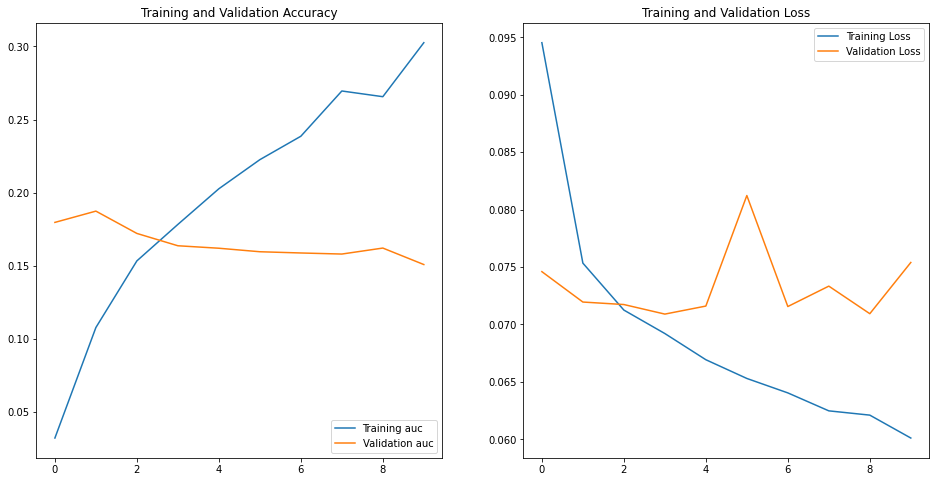

In [16]:
auc = history.history['auc']
val_auc = history.history['val_auc']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, auc, label='Training auc')
plt.plot(epochs_range, val_auc, label='Validation auc')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [13]:
results = model.evaluate(test_ds)
print(results)

78/78 [==============================] - 13s 163ms/step - loss: 0.0867 - auc: 0.7275 - false_negatives: 87.0000 - true_positives: 0.0000e+00
[0.08673236519098282, 0.7275012135505676, 87.0, 0.0]


In [21]:
history.history['evaluation'] = results
history.history

{'loss': [0.12608055770397186,
  0.08349297195672989,
  0.11130350083112717,
  0.08301620930433273,
  0.07850052416324615,
  0.07594470679759979,
  0.0754527822136879,
  0.07115525007247925,
  0.06950052082538605,
  0.06650582700967789],
 'auc': [0.6173259019851685,
  0.7649521827697754,
  0.7744652032852173,
  0.7297800779342651,
  0.7993853688240051,
  0.8074852228164673,
  0.8147390484809875,
  0.8655700087547302,
  0.8577432632446289,
  0.8945533633232117],
 'false_negatives': [41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0],
 'true_positives': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'val_loss': [0.09472941607236862,
  0.084307461977005,
  0.059485454112291336,
  0.08389177918434143,
  0.08924411237239838,
  0.09721383452415466,
  0.10287590324878693,
  0.08853951841592789,
  0.08961668610572815,
  0.09985748678445816],
 'val_auc': [0.7143710255622864,
  0.8392221331596375,
  0.6352968215942383,
  0.7494580149650574,
  0.7030917406082153,


In [18]:
model.load_weights(filepath)
model.save('models/baseline2PR.h5')